# Phase 4 : Feature Engineering + ML Preprocessing + Logistic Regression
Current progress:

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load cleaned dataset
df = pd.read_csv(
    "../data/processed/telco_customer_churn_clean.csv"
)

In [3]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,churn_flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [4]:
df.shape

(7043, 22)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   str    
 4   dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   str    
 7   multiplelines     7043 non-null   str    
 8   internetservice   7043 non-null   str    
 9   onlinesecurity    7043 non-null   str    
 10  onlinebackup      7043 non-null   str    
 11  deviceprotection  7043 non-null   str    
 12  techsupport       7043 non-null   str    
 13  streamingtv       7043 non-null   str    
 14  streamingmovies   7043 non-null   str    
 15  contract          7043 non-null   str    
 16  paperlessbilling  7043 non-null   str    
 17  paymen

In [6]:
# Normalize column names again
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
)

In [7]:
df.columns.tolist()

['customerid',
 'gender',
 'seniorcitizen',
 'partner',
 'dependents',
 'tenure',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod',
 'monthlycharges',
 'totalcharges',
 'churn',
 'churn_flag']

In [8]:
# Verify important columns
required_columns = [
    "customerid",
    "tenure",
    "monthlycharges",
    "totalcharges",
    "contract",
    "internetservice",
    "techsupport",
    "paymentmethod",
    "churn",
    "churn_flag"
]

for col in required_columns:
    print(col, col in df.columns)

customerid True
tenure True
monthlycharges True
totalcharges True
contract True
internetservice True
techsupport True
paymentmethod True
churn True
churn_flag True


In [10]:
# Create a feature DataFrame
df_model = df.copy()

In [11]:
# Feature 1 — Tenure Group
df_model["tenure_group"] = pd.cut(
    df_model["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=[
        "0-6",
        "7-12",
        "13-24",
        "25-48",
        "49-72"
    ]
)

In [12]:
df_model[
    ["tenure", "tenure_group"]
].head(10)

,tenure,tenure_group
0,1,0-6
1,34,25-48
2,2,0-6
3,45,25-48
4,2,0-6
5,8,7-12
6,22,13-24
7,10,7-12
8,28,25-48
9,62,49-72


In [13]:
# Feature 2 — Number of Services
df_model["total_services"] = 0

In [14]:
# Phone 
df_model["total_services"] += (
    df_model["phoneservice"] == "Yes"
).astype(int)

In [15]:
df_model["total_services"] += (
    df_model["multiplelines"] == "Yes"
).astype(int)

In [16]:
# Internet
df_model["total_services"] += (
    df_model["internetservice"] != "No"
).astype(int)

In [17]:
service_columns = [
    "onlinesecurity",
    "onlinebackup",
    "deviceprotection",
    "techsupport",
    "streamingtv",
    "streamingmovies"
]

In [18]:
for col in service_columns:
    df_model["total_services"] += (
        df_model[col] == "Yes"
    ).astype(int)

In [19]:
df_model[
    [
        "phoneservice",
        "internetservice",
        "techsupport",
        "streamingtv",
        "total_services"
    ]
].head()

,phoneservice,internetservice,techsupport,streamingtv,total_services
0,No,DSL,No,No,2
1,Yes,DSL,No,No,4
2,Yes,DSL,No,No,4
3,No,DSL,Yes,No,4
4,Yes,Fiber optic,No,No,2


In [20]:
# Feature 3 — Average Historical Monthly Spend
df_model["avg_monthly_spend"] = np.where(
    df_model["tenure"] > 0,
    df_model["totalcharges"] / df_model["tenure"],
    0
)

In [21]:
df_model[
    [
        "tenure",
        "monthlycharges",
        "totalcharges",
        "avg_monthly_spend"
    ]
].head()

,tenure,monthlycharges,totalcharges,avg_monthly_spend
0,1,29.85,29.85,29.850000
1,34,56.95,1889.50,55.573529
2,2,53.85,108.15,54.075000
3,45,42.30,1840.75,40.905556
4,2,70.70,151.65,75.825000


In [22]:
# Feature 4 — Automatic Payment
automatic_methods = [
    "Bank transfer (automatic)",
    "Credit card (automatic)"
]

In [23]:
df_model["automatic_payment"] = (
    df_model["paymentmethod"]
    .isin(automatic_methods)
    .astype(int)
)

In [24]:
df_model[
    [
        "paymentmethod",
        "automatic_payment"
    ]
].head(10)

,paymentmethod,automatic_payment
0,Electronic check,0
1,Mailed check,0
2,Mailed check,0
3,Bank transfer (automatic),1
4,Electronic check,0
5,Electronic check,0
6,Credit card (automatic),1
7,Mailed check,0
8,Electronic check,0
9,Bank transfer (automatic),1


In [25]:
# Feature 5 — Month-to-Month Customer
df_model["is_month_to_month"] = (
    df_model["contract"] == "Month-to-month"
).astype(int)

In [26]:
# Feature 6 — Has Technical Support
df_model["has_tech_support"] = (
    df_model["techsupport"] == "Yes"
).astype(int)

In [27]:
new_features = [
    "tenure_group",
    "total_services",
    "avg_monthly_spend",
    "automatic_payment",
    "is_month_to_month",
    "has_tech_support"
]

df_model[new_features].head()

,tenure_group,total_services,avg_monthly_spend,automatic_payment,is_month_to_month,has_tech_support
0,0-6,2,29.850000,0,1,0
1,25-48,4,55.573529,0,0,0
2,0-6,4,54.075000,0,1,0
3,25-48,4,40.905556,1,0,1
4,0-6,2,75.825000,0,1,0


In [29]:
# Prepare X and y
y = df_model["churn_flag"] # Target

In [ ]:
X = df_model.drop(
    columns=[
        "customerid",
        "churn",
        "churn_flag"
    ]
)  # Features

In [31]:
# Verify X
X.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,...,paperlessbilling,paymentmethod,monthlycharges,totalcharges,tenure_group,total_services,avg_monthly_spend,automatic_payment,is_month_to_month,has_tech_support
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Yes,Electronic check,29.85,29.85,0-6,2,29.850000,0,1,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,Mailed check,56.95,1889.50,25-48,4,55.573529,0,0,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Yes,Mailed check,53.85,108.15,0-6,4,54.075000,0,1,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,Bank transfer (automatic),42.30,1840.75,25-48,4,40.905556,1,0,1
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Yes,Electronic check,70.70,151.65,0-6,2,75.825000,0,1,0


In [32]:
X.shape

(7043, 25)

In [33]:
y.shape

(7043,)

In [34]:
y.value_counts()

churn_flag
0    5174
1    1869
Name: count, dtype: int64

In [35]:
# Train/Test Split
# Import
from sklearn.model_selection import train_test_split


In [36]:
# Split:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [37]:
print("Overall:")
print(y.value_counts(normalize=True))

print("\nTrain:")
print(y_train.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))

Overall:
churn_flag
0    0.73463
1    0.26537
Name: proportion, dtype: float64

Train:
churn_flag
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Test:
churn_flag
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [38]:
# Identify Numeric and Categorical Features
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

In [39]:
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

C:\Users\Dell\AppData\Local\Temp\ipykernel_12760\3274505626.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [40]:
print("Numeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numeric Features:
['seniorcitizen', 'tenure', 'monthlycharges', 'totalcharges', 'total_services', 'avg_monthly_spend', 'automatic_payment', 'is_month_to_month', 'has_tech_support']

Categorical Features:
['gender', 'partner', 'dependents', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'tenure_group']


In [41]:
# Build Preprocessing Pipeline
# import
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [42]:
# Numerical Pipeline
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

In [43]:
# Categorical Pipeline
categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [44]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [45]:
# Our First ML Model
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

In [46]:
# Build complete ML Pipeline
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

In [47]:
# Train the model
logistic_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['gender','seniorcitizen','partner',...,'automatic_payment', 'is_month_to_month','has_tech_support']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying

In [48]:
# Make predictions
y_pred = logistic_model.predict(
    X_test
)

In [49]:
y_prob = logistic_model.predict_proba(
    X_test
)[:, 1]

In [50]:
# Evaluate Logistic Regression
# import
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [51]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [52]:
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Accuracy : 0.7977
Precision: 0.6551
Recall   : 0.5027
F1 Score : 0.5688
ROC-AUC  : 0.845


In [53]:
# Classification Report
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.66      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [55]:
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[936,  99],
       [186, 188]])

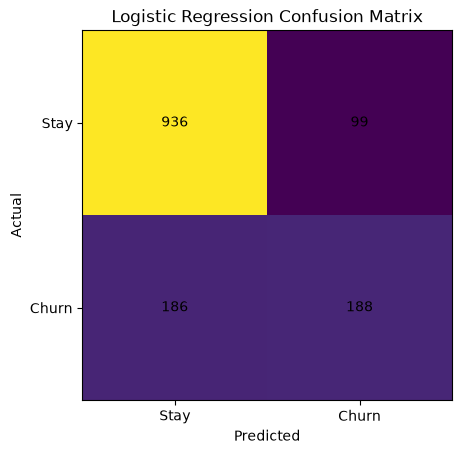

In [56]:
# Visualize Confusion Matrix
fig, ax = plt.subplots()

image = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(
    ["Stay", "Churn"]
)

ax.set_yticklabels(
    ["Stay", "Churn"]
)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

In [57]:
# ROC Curve
# import
from sklearn.metrics import roc_curve

In [58]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

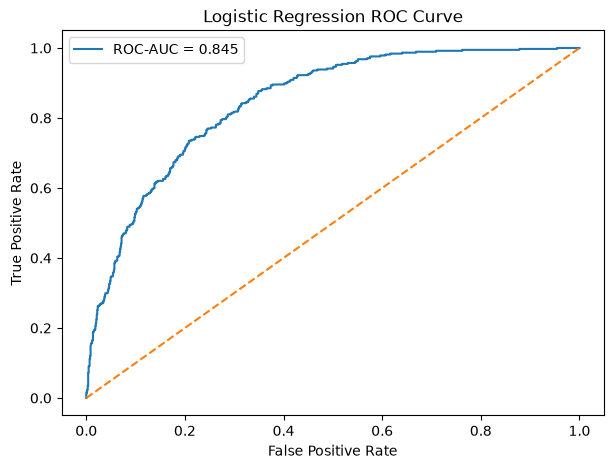

In [59]:
# Plot
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Logistic Regression ROC Curve"
)

plt.legend()

plt.show()

In [60]:
# Precision-Recall Curve
# Import
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

In [61]:
# Calculate
precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_test,
        y_prob
    )
)

In [62]:
# Average precision
pr_auc = average_precision_score(
    y_test,
    y_prob
)

print(
    "Average Precision:",
    round(pr_auc, 4)
)

Average Precision: 0.6516


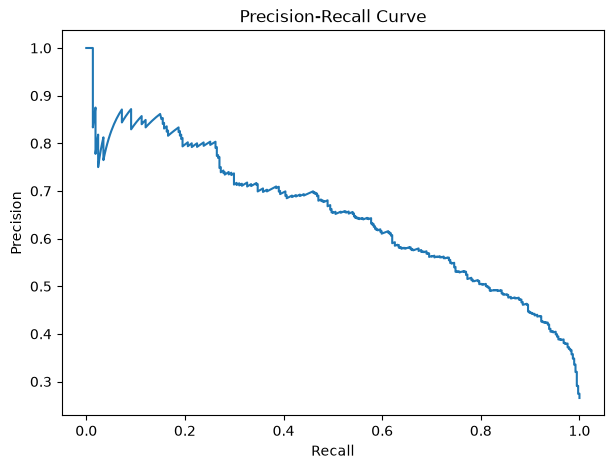

In [63]:
# Plot
plt.figure(figsize=(7, 5))

plt.plot(
    recall_values,
    precision_values
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve"
)

plt.show()

In [64]:
# first model results table
results = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression"
        ],
        "Accuracy": [
            accuracy
        ],
        "Precision": [
            precision
        ],
        "Recall": [
            recall
        ],
        "F1": [
            f1
        ],
        "ROC_AUC": [
            roc_auc
        ],
        "PR_AUC": [
            pr_auc
        ]
    }
)

results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.797729,0.655052,0.502674,0.568835,0.845033,0.651557


In [65]:
prediction_results = X_test.copy()

prediction_results[
    "actual_churn"
] = y_test.values

prediction_results[
    "predicted_churn"
] = y_pred

prediction_results[
    "churn_probability"
] = y_prob

In [66]:
prediction_results[
    [
        "actual_churn",
        "predicted_churn",
        "churn_probability"
    ]
].head(20)

,actual_churn,predicted_churn,churn_probability
437,0,0,0.043407
2280,0,1,0.695370
2235,0,0,0.057669
4460,0,0,0.336958
3761,0,0,0.027606
5748,0,1,0.550442
3568,0,0,0.387518
2976,0,0,0.110074
5928,0,0,0.005390
1639,1,0,0.303037


In [67]:
prediction_results.sort_values(
    by="churn_probability",
    ascending=False
)[
    [
        "tenure",
        "contract",
        "monthlycharges",
        "internetservice",
        "techsupport",
        "churn_probability",
        "actual_churn"
    ]
].head(20)

,tenure,contract,monthlycharges,internetservice,techsupport,churn_probability,actual_churn
3380,1,Month-to-month,95.10,Fiber optic,No,0.907684,1
6894,3,Month-to-month,105.90,Fiber optic,No,0.893097,1
2797,3,Month-to-month,100.95,Fiber optic,No,0.891681,1
6866,1,Month-to-month,95.45,Fiber optic,No,0.889195,1
3727,3,Month-to-month,96.60,Fiber optic,No,0.879845,1
3346,2,Month-to-month,84.05,Fiber optic,No,0.879460,0
4585,1,Month-to-month,85.05,Fiber optic,No,0.873224,1
933,4,Month-to-month,84.60,Fiber optic,No,0.869573,1
935,4,Month-to-month,83.25,Fiber optic,No,0.865879,0
582,4,Month-to-month,89.20,Fiber optic,No,0.864629,1
